In [136]:
import pandas as pd 
import numpy as np 
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt 
import seaborn as sns 

import gower
from sklearn.cluster import DBSCAN

import statsmodels.formula.api as smf 
from scipy.stats import spearmanr, sem, pearsonr, norm, chi2

from copy import deepcopy

import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [137]:
CLUSTER_COLUMNS = ['CONFIG_playerCount', 'CONFIG_numRounds', 'CONFIG_showNRounds', 
                   'CONFIG_MPCR', 'CONFIG_allOrNothing', 'CONFIG_chat', 'CONFIG_defaultContribProp', 
                   'CONFIG_rewardExists', 'CONFIG_showOtherSummaries', "CONFIG_punishmentCost", "CONFIG_punishmentTech",
                   'CONFIG_showPunishmentId']

def fit_cluster_params(group, outcome):
    model = smf.ols(f"{outcome} ~ CONFIG_punishmentExists", data=group).fit()
    return pd.Series({
        'estimate': model.params["CONFIG_punishmentExists[T.True]"],
        'se': model.bse["CONFIG_punishmentExists[T.True]"]
    })

def calc_q_i2(df_effect_sizes):
    n = len(df_effect_sizes)
    df_effect_sizes["weight"] = 1 / df_effect_sizes["treatment_effect_se"]**2
    weighted_effect_mean = ((df_effect_sizes["weight"] * df_effect_sizes["treatment_effect_mean"]) / df_effect_sizes["weight"].sum()).sum()
    
    cochran_q = (df_effect_sizes["weight"] * (df_effect_sizes["treatment_effect_mean"] - weighted_effect_mean)**2).sum()
    
    i2 = (cochran_q - (n-1)) / cochran_q
    
    
    return {"Q":cochran_q.round(2), "Q_pval":(1 - chi2.cdf(abs(cochran_q), df=n-1)).round(3), "Q_dof":n-1, "i2":i2.round(2)}

In [138]:
# Load dataframes 
directory = "./data/"
df_paired_val = pd.read_csv(directory + "df_paired_val.csv")
df_paired_learn = pd.read_csv(directory + "df_paired_learn.csv")
df_analysis_val = pd.read_csv(directory + "df_analysis_val.csv")
df_analysis_learn = pd.read_csv(directory + "df_analysis_learn.csv")
df_rounds_learn = pd.read_csv(directory + "df_rounds_learn.csv")
df_rounds_val = pd.read_csv(directory + "df_rounds_val.csv")

In [139]:
df_paired_val["ols_model"] = df_paired_val["CONFIG_configId"].map(df_analysis_val.query("valid_number_of_starting_players").groupby("CONFIG_configId").apply(lambda x: smf.ols("itt_relative_efficiency ~ CONFIG_punishmentExists", data=x).fit()))
df_paired_val["treatment_effect"] = df_paired_val["treatment_itt_efficiency"] - df_paired_val["control_itt_efficiency"]
df_paired_val["treatment_effect_mean"] = df_paired_val["ols_model"].apply(lambda x: x.params["CONFIG_punishmentExists[T.True]"])
df_paired_val["treatment_effect_se"] = df_paired_val["ols_model"].apply(lambda x: x.bse["CONFIG_punishmentExists[T.True]"])

/var/folders/t5/pjvp_tpd6tl9tzz8k2kx6hd80000gq/T/ipykernel_53190/1120114444.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_paired_val["ols_model"] = df_paired_val["CONFIG_configId"].map(df_analysis_val.query("valid_number_of_starting_players").groupby("CONFIG_configId").apply(lambda x: smf.ols("itt_relative_efficiency ~ CONFIG_punishmentExists", data=x).fit()))


In [146]:
%%capture
df_analysis_learn_kmeans = deepcopy(df_analysis_learn)
df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]] = MinMaxScaler().fit_transform(df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]])

kmeans = KMeans(n_clusters=20, random_state=2024)
df_cluster_learn = deepcopy(df_analysis_learn_kmeans).assign(cluster=kmeans.fit_predict(df_analysis_learn_kmeans[CLUSTER_COLUMNS])).query("valid_number_of_starting_players")
df_cluster_params = df_cluster_learn.groupby("cluster").apply(lambda x: fit_cluster_params(x, "itt_relative_efficiency")).reset_index()

In [148]:
df_cluster_learn.groupby("cluster")["CONFIG_configId"].nunique().sort_values(), df_cluster_learn.groupby("cluster").size().sort_values()

(cluster
 5      3
 1      4
 7      5
 18     5
 15     6
 10     6
 14     6
 19     7
 2      8
 8      9
 17    10
 16    10
 13    10
 0     11
 6     11
 4     11
 12    11
 9     11
 3     12
 11    14
 Name: CONFIG_configId, dtype: int64,
 cluster
 1      7
 5      8
 18     9
 7     10
 15    11
 14    11
 19    13
 10    13
 2     17
 16    18
 8     18
 17    19
 6     20
 9     21
 4     21
 3     21
 12    22
 13    22
 0     22
 11    32
 dtype: int64)

In [110]:
# Create clusters 
# gower_dist_matrix = gower.gower_matrix(df_analysis_learn[CLUSTER_COLUMNS])
# dbscan = DBSCAN(eps=0.130, metric="precomputed")
# dbscan_clusters = dbscan.fit_predict(gower_dist_matrix)
# # dbscan_clusters = KMeans(n_clusters=20).fit_predict(StandardScaler().fit_transform(df_analysis_learn[CLUSTER_COLUMNS]))

# df_cluster_learn = deepcopy(df_analysis_learn).assign(cluster=dbscan_clusters).query("valid_number_of_starting_players")
# # df_cluster_learn["cluster"] = df_cluster_learn["leaf_id"]
# df_cluster_params = df_cluster_learn.groupby("cluster").apply(lambda x: fit_cluster_params(x, "itt_relative_efficiency")).reset_index()

In [127]:
valid_game_ids = set(df_analysis_learn.query("valid_number_of_starting_players")["gameId"]).union(set(df_analysis_val.query("valid_number_of_starting_players")["gameId"]))

# Figure 2 code

In [ ]:

# Style setup
plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['grid.alpha'] = 0.0

# Define color schemes
wave_colors = {
    'Learning dataset': '#1f77b4',    # Blue
    'Validation dataset': '#ff7f0e'    # Orange
}

# Colors for learning/validation experiments
learning_colors = sns.color_palette("Blues", n_colors=4)
learning_punishment_colors = {
    'Without punishment': learning_colors[1],
    'With punishment': learning_colors[2]
}

validation_colors = sns.color_palette("Oranges", n_colors=4)
validation_punishment_colors = {
    'Without punishment': validation_colors[1],
    'With punishment': validation_colors[2]
}

punishment_markers = {
    'Without punishment': 'o',  # Circle
    'With punishment': '^'     # Triangle
}

# Create figure (Nature/Science standard size)
height_mm = 220  # Reduced from 240
width_mm = 183
width_inches = width_mm / 25.4
height_inches = height_mm / 25.4
fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)

# Create GridSpec with adjusted ratios
gs = GridSpec(5, 3, 
              height_ratios=[1.5, 2, 1.5, 2, 1.5],
              hspace=0.4,    # This will be overridden by per-row spacing
              wspace=0.25)

# Get the GridSpec's position
pos = gs.get_grid_positions(fig)

# Manually adjust the height positions to create different spacing between paired panels
# Original positions are in figure coordinates (0-1)
row_positions = pos[0]  # These are the y-positions of each row

# Adjust positions to bring E closer to D and G closer to F
# Move row 2 (E) up closer to row 1 (D)
row_positions[2] = row_positions[1] - 0.15  # Adjust this value to control D-E spacing

# Move row 4 (G) up closer to row 3 (F)
row_positions[4] = row_positions[3] - 0.15  # Adjust this value to control F-G spacing

# Update GridSpec with new positions
gs.update(top=0.95, bottom=0.08, hspace=0.4)



# Create subplots
ax_coins = fig.add_subplot(gs[0, 0])
ax_efficiency = fig.add_subplot(gs[0, 1])
ax_normalized_efficiency = fig.add_subplot(gs[0, 2])
ax_learning_efficiency = fig.add_subplot(gs[1, :])
ax_learning_effect = fig.add_subplot(gs[2, :], sharex=ax_learning_efficiency)
ax_validation_efficiency = fig.add_subplot(gs[3, :])
ax_validation_effect = fig.add_subplot(gs[4, :], sharex=ax_validation_efficiency)

# Common parameters
err_kws = {'linewidth': 1.0}
title_fontsize = 11
label_fontsize = 9
tick_fontsize = 8
legend_fontsize = 8

# Panel A: Coins
sns.pointplot(
    x="CONFIG_punishmentExists", y="coins_contributed",
    hue="wave", dodge=0.15,
    markers=['o', 'o'], linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_coins, order=[False, True],
    palette=[wave_colors['Learning dataset'], wave_colors['Validation dataset']],
    data=(
        pd.concat([
            df_rounds_learn.merge(df_analysis_learn[["gameId", "CONFIG_punishmentExists"]],
                                how="left", on="gameId").assign(wave="Learning dataset"),
            df_rounds_val.merge(df_analysis_val[["gameId", "CONFIG_punishmentExists"]],
                              how="left", on="gameId").assign(wave="Validation dataset")
        ], ignore_index=True)
        .rename(columns={"data.contribution": "coins_contributed"})
        .assign(coins_contributed=lambda x: x.coins_contributed / 20)
        .query("gameId in @valid_game_ids")
    )
)
ax_coins.legend().remove()

# Panel B: Efficiency
sns.pointplot(
    x="CONFIG_punishmentExists", y="itt_efficiency",
    hue="wave", dodge=0.15,
    markers=['o', 'o'], linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_efficiency, order=[False, True],
    palette=[wave_colors['Learning dataset'], wave_colors['Validation dataset']],
    data=pd.concat([
        df_analysis_learn.assign(wave="Learning dataset").query("valid_number_of_starting_players"),
        df_analysis_val.assign(wave="Validation dataset").query("valid_number_of_starting_players")
    ], ignore_index=True)
)
ax_efficiency.legend().remove()

# Panel C: Normalized Efficiency
sns.pointplot(
    x="CONFIG_punishmentExists", y="itt_relative_efficiency",
    hue="wave", dodge=0.15,
    markers=['o', 'o'], linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_normalized_efficiency, order=[False, True],
    palette=[wave_colors['Learning dataset'], wave_colors['Validation dataset']],
    data=pd.concat([
        df_analysis_learn.assign(wave="Learning dataset").query("valid_number_of_starting_players"),
        df_analysis_val.assign(wave="Validation dataset").query("valid_number_of_starting_players")
    ], ignore_index=True)
)
ax_normalized_efficiency.legend().remove()

# Style top row plots
for ax in [ax_coins, ax_efficiency, ax_normalized_efficiency]:
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_xticks(ticks=range(2))
    ax.set_xticklabels(labels=["Without\npunishment", "With\npunishment"], fontsize=label_fontsize)
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

ax_coins.set_ylabel("Average contribution", fontsize=label_fontsize)
ax_efficiency.set_ylabel("Efficiency", fontsize=label_fontsize)
ax_normalized_efficiency.set_ylabel("Normalized efficiency", fontsize=label_fontsize)

ax_coins.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax_coins.set_ylim(0.72, 0.86)
ax_efficiency.set_ylim(0.55, 0.90)
ax_normalized_efficiency.set_ylim(0.55, 0.90)

# Add legend for top row
handles, labels = ax_coins.get_legend_handles_labels()
fig.legend(handles, ['Learning dataset', 'Validation dataset'],
          loc='upper center',
          bbox_to_anchor=(0.5, 0.98),
          ncol=2,
          frameon=False,
          fontsize=legend_fontsize,
          borderaxespad=0,
          handlelength=1.5)

# Learning panels (D, E)
df_cluster_learn = df_cluster_learn.assign(
    CONFIG_punishmentExists=lambda x: x.CONFIG_punishmentExists.map(
        {False: 'Without punishment', True: 'With punishment'}
    )
).dropna(subset=['CONFIG_punishmentExists'])

hue_order_learn = ['Without punishment', 'With punishment']
hue_order_learn = [hue for hue in hue_order_learn if hue in df_cluster_learn['CONFIG_punishmentExists'].unique()]
markers_learn = [punishment_markers[hue] for hue in hue_order_learn]
palette_learn = [learning_punishment_colors[hue] for hue in hue_order_learn]

# Panel D: Learning Efficiency
sns.pointplot(
    x="cluster", y="itt_relative_efficiency", hue="CONFIG_punishmentExists",
    data=df_cluster_learn,
    order=df_cluster_params.sort_values("estimate")["cluster"].astype(str).values,
    dodge=0.4, markers=markers_learn, linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_learning_efficiency,
    palette=palette_learn,
    hue_order=hue_order_learn
)

ax_learning_efficiency.legend(
    title='', loc='lower right', frameon=False, fontsize=legend_fontsize
)

# Panel E: Learning Effect
df_cluster_params_sorted = df_cluster_params.sort_values("estimate")
bar_colors = [learning_punishment_colors['Without punishment'] if x > 0 else learning_punishment_colors['With punishment']
              for x in df_cluster_params_sorted["estimate"]]

sns.barplot(
    x="cluster", y="estimate",
    data=df_cluster_params_sorted,
    palette=bar_colors,
    order=df_cluster_params_sorted["cluster"].astype(str).values,
    ax=ax_learning_effect,
    errorbar="se"
)

ax_learning_effect.errorbar(
    x=range(len(df_cluster_params_sorted)),
    y=df_cluster_params_sorted["estimate"].values,
    yerr=(1.96 * df_cluster_params_sorted["se"]).values,
    linestyle="", color="black", linewidth=0.5, zorder=1000
)

# Validation panels (F, G)
df_analysis_val_processed = df_analysis_val.query("valid_number_of_starting_players").assign(
    CONFIG_punishmentExists=lambda x: x.CONFIG_punishmentExists.map(
        {False: 'Without punishment', True: 'With punishment'}
    )
).dropna(subset=['CONFIG_punishmentExists'])

hue_order_val = ['Without punishment', 'With punishment']
hue_order_val = [hue for hue in hue_order_val if hue in df_analysis_val_processed['CONFIG_punishmentExists'].unique()]
markers_val = [punishment_markers[hue] for hue in hue_order_val]
palette_val = [validation_punishment_colors[hue] for hue in hue_order_val]

# Panel F: Validation Efficiency
sns.pointplot(
    x="CONFIG_configId", y="itt_relative_efficiency", hue="CONFIG_punishmentExists",
    data=df_analysis_val_processed,
    order=df_paired_val.sort_values("treatment_effect_mean")["CONFIG_configId"].astype(str).values,
    dodge=0.4, markers=markers_val, linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_validation_efficiency,
    palette=palette_val,
    hue_order=hue_order_val
)

ax_validation_efficiency.legend(
    title='', loc='lower right', frameon=False, fontsize=legend_fontsize
)

# Panel G: Validation Effect
df_paired_val_sorted = df_paired_val.sort_values("treatment_effect_mean")
bar_colors_val = [validation_punishment_colors['Without punishment'] if x > 0 else validation_punishment_colors['With punishment']
                 for x in df_paired_val_sorted["treatment_effect_mean"]]

sns.barplot(
    x="CONFIG_configId", y="treatment_effect_mean",
    data=df_paired_val_sorted,
    palette=bar_colors_val,
    order=df_paired_val_sorted["CONFIG_configId"].astype(str).values,
    ax=ax_validation_effect,
    errorbar="se"
)

ax_validation_effect.errorbar(
    x=range(len(df_paired_val_sorted)),
    y=df_paired_val_sorted["treatment_effect_mean"].values,
    yerr=(1.96 * df_paired_val_sorted["treatment_effect_se"]).values,
    linestyle="", color="black", linewidth=0.5, zorder=1000
)

# Add reference lines
ax_learning_efficiency.axhline(
    y=df_cluster_learn["itt_relative_efficiency"].mean(),
    color="black", linestyle="--", alpha=0.3, zorder=-10
)
ax_learning_effect.axhline(0, linestyle="--", color="black", alpha=0.3)
ax_validation_efficiency.axhline(
    y=df_analysis_val_processed["itt_relative_efficiency"].mean(),
    color="black", linestyle="--", alpha=0.3, zorder=-10
)
ax_validation_effect.axhline(0, linestyle="--", color="black", alpha=0.3)

# Style all panels D through G
for ax in [ax_learning_efficiency, ax_learning_effect, ax_validation_efficiency, ax_validation_effect]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.set_xlabel("")
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

# Remove x-tick labels for efficiency panels
ax_learning_efficiency.set_xticklabels([])
ax_validation_efficiency.set_xticklabels([])

# Set shared x-axis labels
ax_learning_effect.set_xlabel("Learning Experiments", fontsize=label_fontsize, labelpad=8)
ax_validation_effect.set_xlabel("Validation Experiments", fontsize=label_fontsize, labelpad=8)

# Set shared y-axis ranges
min_efficiency = min(ax_learning_efficiency.get_ylim()[0], ax_validation_efficiency.get_ylim()[0])
max_efficiency = max(ax_learning_efficiency.get_ylim()[1], ax_validation_efficiency.get_ylim()[1])
ax_learning_efficiency.set_ylim(min_efficiency, max_efficiency)
ax_validation_efficiency.set_ylim(min_efficiency, max_efficiency)

min_effect = min(ax_learning_effect.get_ylim()[0], ax_validation_effect.get_ylim()[0])
max_effect = max(ax_learning_effect.get_ylim()[1], ax_validation_effect.get_ylim()[1])
ax_learning_effect.set_ylim(min_effect, max_effect)
ax_validation_effect.set_ylim(min_effect, max_effect)

# Add panel labels
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
axes = [
    ax_coins, ax_efficiency, ax_normalized_efficiency,
    ax_learning_efficiency, ax_learning_effect,
    ax_validation_efficiency, ax_validation_effect
]

for label, ax in zip(labels, axes):
    ax.text(0.02, 0.98, label, transform=ax.transAxes,
            fontsize=title_fontsize, fontweight='bold', 
            va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.1))

# Fine-tune the layout with the new spacing
plt.subplots_adjust(
    left=0.12,      # Left margin for y-axis labels
    right=0.95,     # Right margin
    top=0.95,       # Top margin
    bottom=0.08,    # Bottom margin for x-axis labels
    hspace=0.4      # This provides space for labels between other panels
)

# Add extra adjustment for paired panels
for ax1, ax2 in [(ax_learning_efficiency, ax_learning_effect), 
                 (ax_validation_efficiency, ax_validation_effect)]:
    # Get the positions of both axes
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    
    # Move the second axis up closer to the first
    new_pos2 = [pos2.x0, pos2.y0 + 0.05, pos2.width, pos2.height]  # Adjust the 0.05 to control spacing
    ax2.set_position(new_pos2)
    
# Add I² statistics
learn_het_stats = calc_q_i2(df_cluster_params.rename(
    columns={"estimate": "treatment_effect_mean", "se": "treatment_effect_se"}))

val_het_stats = calc_q_i2(df_paired_val[["treatment_effect_mean", "treatment_effect_se"]])

# Add I² annotations
ax_learning_effect.text(0.98, 0.05, f'$I^2 = {learn_het_stats["i2"]}$',
                       transform=ax_learning_effect.transAxes,
                       fontsize=legend_fontsize, va='bottom', ha='right')
ax_validation_effect.text(0.98, 0.05, f'$I^2 = {val_het_stats["i2"]}$',
                         transform=ax_validation_effect.transAxes,
                         fontsize=legend_fontsize, va='bottom', ha='right')

# Set y-axis labels for efficiency and effect panels
ax_learning_efficiency.set_ylabel("Normalized Efficiency", fontsize=label_fontsize)
ax_learning_effect.set_ylabel("Punishment Effect", fontsize=label_fontsize)
ax_validation_efficiency.set_ylabel("Normalized Efficiency", fontsize=label_fontsize)
ax_validation_effect.set_ylabel("Punishment Effect", fontsize=label_fontsize)

# Fine-tune the layout
plt.subplots_adjust(
    left=0.12,      # Increased left margin for y-axis labels
    right=0.95,     # Reduced right margin
    top=0.95,       # Reduced top margin
    bottom=0.08,    # Slightly increased bottom margin for x-axis labels
    hspace=0.2      # Reduced vertical spacing between subplots
)


# Save the figure
plt.savefig('heterogeneity_analysis.pdf', 
            dpi=300, 
            bbox_inches='tight',
            metadata={'Creator': 'Matplotlib'})

# Optionally, display the figure
plt.show()

In [ ]:
df_rounds = (pd.concat([df_rounds_learn.merge(df_analysis_learn[["gameId", "CONFIG_punishmentExists"]], how="left", on="gameId").assign(wave="$D_{learn}$"),
                              df_rounds_val.merge(df_analysis_val[["gameId", "CONFIG_punishmentExists"]], how="left", on="gameId").assign(wave="$D_{test}$")], ignore_index=True)
                    .rename(columns={"data.contribution":"coins_contributed"})).assign(coins_contributed = lambda x: x.coins_contributed/20)

print("contribution")
print("learn, no punishment:", df_rounds[(df_rounds.wave == "$D_{learn}$") 
                 & (df_rounds.CONFIG_punishmentExists==False)]['coins_contributed'].mean())
print("learn,  punishment:", df_rounds[(df_rounds.wave == "$D_{learn}$") 
                 & (df_rounds.CONFIG_punishmentExists==True)]['coins_contributed'].mean())

print("-----")
print("validation, no punishment:", df_rounds[(df_rounds.wave == "$D_{test}$") 
                 & (df_rounds.CONFIG_punishmentExists==False)]['coins_contributed'].mean())


print("validation,  punishment:", df_rounds[(df_rounds.wave == "$D_{test}$") 
                 & (df_rounds.CONFIG_punishmentExists==True)]['coins_contributed'].mean())

#Average coin contributed for the learning dataset with no punishment is: 0.73
#Average coin contributed for the learning dataset with no punishment is: 0.8

In [ ]:
df_games = pd.concat([df_analysis_learn.assign(wave = "$D_{learn}$").query("valid_number_of_starting_players"),
                              df_analysis_val.assign(wave = "$D_{test}$").query("valid_number_of_starting_players")], ignore_index=True)

print("efficiency")
print("learn, no punishment", df_games[(df_games.wave == "$D_{learn}$") & df_games.CONFIG_punishmentExists==False]['itt_efficiency'].mean())
print("learn, punishment", df_games[(df_games.wave == "$D_{learn}$") & df_games.CONFIG_punishmentExists==True]['itt_efficiency'].mean())
print("----")
print("validation, no punishment", df_games[(df_games.wave == "$D_{test}$") & df_games.CONFIG_punishmentExists==False]['itt_efficiency'].mean())
print("validation, punishment", df_games[(df_games.wave == "$D_{test}$") & df_games.CONFIG_punishmentExists==True]['itt_efficiency'].mean())


In [ ]:
df_games = pd.concat([df_analysis_learn.assign(wave = "$D_{learn}$").query("valid_number_of_starting_players"),
                              df_analysis_val.assign(wave = "$D_{test}$").query("valid_number_of_starting_players")], ignore_index=True)

print("Normalized efficiency")
print("learn, no punishment", df_games[(df_games.wave == "$D_{learn}$") & df_games.CONFIG_punishmentExists==False]['itt_relative_efficiency'].mean())
print("learn, with punishment", df_games[(df_games.wave == "$D_{learn}$") & df_games.CONFIG_punishmentExists==True]['itt_relative_efficiency'].mean())
print("----")
print("validation, no punishment", df_games[(df_games.wave == "$D_{test}$") & df_games.CONFIG_punishmentExists==False]['itt_relative_efficiency'].mean())
print("validation, with punishment", df_games[(df_games.wave == "$D_{test}$") & df_games.CONFIG_punishmentExists==True]['itt_relative_efficiency'].mean())


# Remove panel B 

/var/folders/t5/pjvp_tpd6tl9tzz8k2kx6hd80000gq/T/ipykernel_53190/2209900045.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t5/pjvp_tpd6tl9tzz8k2kx6hd80000gq/T/ipykernel_53190/2209900045.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t5/pjvp_tpd6tl9tzz8k2kx6hd80000gq/T/ipykernel_53190/2537857632.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_effect_sizes["weight"] = 1 / df_effect_sizes["treatment_effe

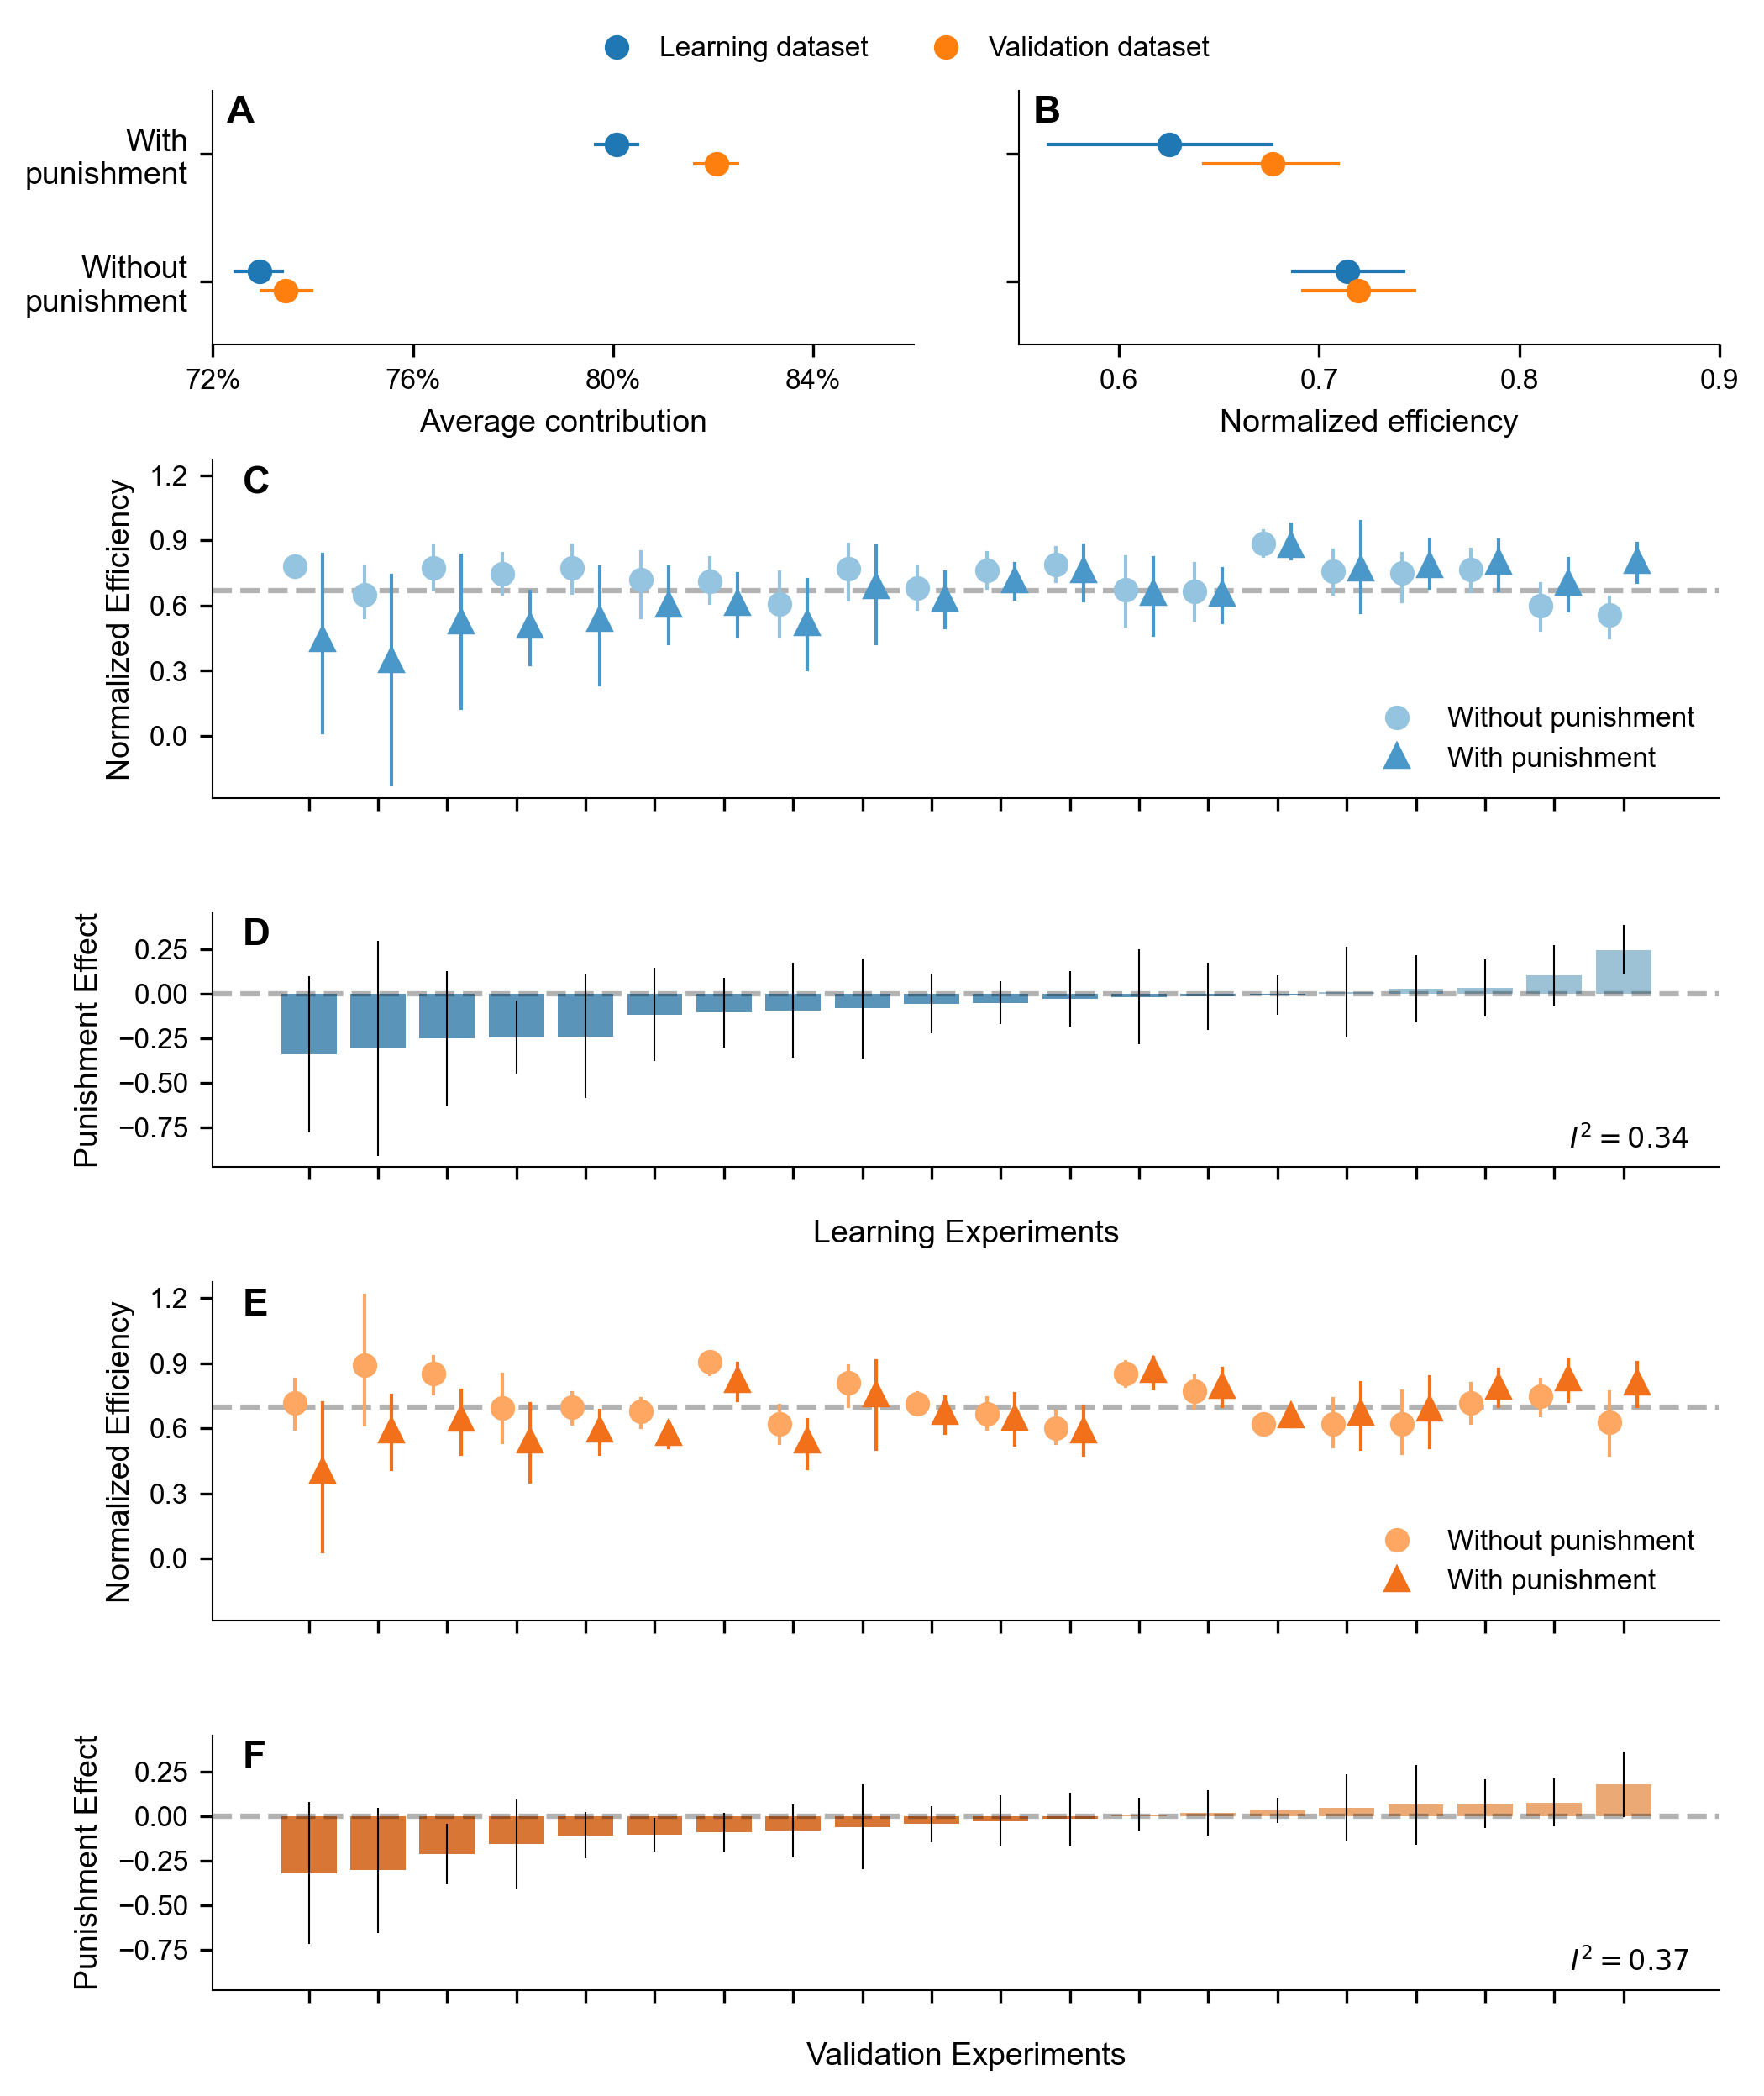

In [149]:

# Style setup
plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['grid.alpha'] = 0.0

# Define color schemes
wave_colors = {
    'Learning dataset': '#1f77b4',    # Blue
    'Validation dataset': '#ff7f0e'    # Orange
}

# Colors for learning/validation experiments
learning_colors = sns.color_palette("Blues", n_colors=4)
learning_punishment_colors = {
    'Without punishment': learning_colors[1],
    'With punishment': learning_colors[2]
}

validation_colors = sns.color_palette("Oranges", n_colors=4)
validation_punishment_colors = {
    'Without punishment': validation_colors[1],
    'With punishment': validation_colors[2]
}

punishment_markers = {
    'Without punishment': 'o',  # Circle
    'With punishment': '^'     # Triangle
}

# Create figure (Nature/Science standard size)
height_mm = 220  # Reduced from 240
width_mm = 183
width_inches = width_mm / 25.4
height_inches = height_mm / 25.4
fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)

# Create GridSpec with adjusted ratios
gs = GridSpec(5, 2, 
              height_ratios=[1.5, 2, 1.5, 2, 1.5],
              hspace=0.4,    # This will be overridden by per-row spacing
              wspace=0.15)

# Get the GridSpec's position
pos = gs.get_grid_positions(fig)

# Manually adjust the height positions to create different spacing between paired panels
# Original positions are in figure coordinates (0-1)
row_positions = pos[0]  # These are the y-positions of each row

# Adjust positions to bring E closer to D and G closer to F
# Move row 2 (E) up closer to row 1 (D)
row_positions[2] = row_positions[1] - 0.15  # Adjust this value to control D-E spacing

# Move row 4 (G) up closer to row 3 (F)
row_positions[4] = row_positions[3] - 0.15  # Adjust this value to control F-G spacing

# Update GridSpec with new positions
gs.update(top=0.95, bottom=0.08, hspace=0.4)



# Create subplots
ax_coins = fig.add_subplot(gs[0, 0])
# ax_efficiency = fig.add_subplot(gs[0, 1])
ax_normalized_efficiency = fig.add_subplot(gs[0, 1])
ax_learning_efficiency = fig.add_subplot(gs[1, :])
ax_learning_effect = fig.add_subplot(gs[2, :], sharex=ax_learning_efficiency)
ax_validation_efficiency = fig.add_subplot(gs[3, :])
ax_validation_effect = fig.add_subplot(gs[4, :], sharex=ax_validation_efficiency)

# Common parameters
err_kws = {'linewidth': 1.0}
title_fontsize = 11
label_fontsize = 9
tick_fontsize = 8
legend_fontsize = 8

# Panel A: Coins
sns.pointplot(
    y="CONFIG_punishmentExists", x="coins_contributed", orient="y",
    hue="wave", dodge=0.15,
    markers=['o', 'o'], linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_coins, order=[True, False],
    palette=[wave_colors['Learning dataset'], wave_colors['Validation dataset']],
    data=(
        pd.concat([
            df_rounds_learn.merge(df_analysis_learn[["gameId", "CONFIG_punishmentExists"]],
                                how="left", on="gameId").assign(wave="Learning dataset"),
            df_rounds_val.merge(df_analysis_val[["gameId", "CONFIG_punishmentExists"]],
                              how="left", on="gameId").assign(wave="Validation dataset")
        ], ignore_index=True)
        .rename(columns={"data.contribution": "coins_contributed"})
        .assign(coins_contributed=lambda x: x.coins_contributed / 20)
        .query("gameId in @valid_game_ids")
    )
)
ax_coins.legend().remove()

# Panel B: Normalized Efficiency
sns.pointplot(
    y="CONFIG_punishmentExists", x="itt_relative_efficiency", orient="y",
    hue="wave", dodge=0.15,
    markers=['o', 'o'], linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_normalized_efficiency, order=[True, False],
    palette=[wave_colors['Learning dataset'], wave_colors['Validation dataset']],
    data=pd.concat([
        df_analysis_learn.assign(wave="Learning dataset").query("valid_number_of_starting_players"),
        df_analysis_val.assign(wave="Validation dataset").query("valid_number_of_starting_players")
    ], ignore_index=True)
)
ax_normalized_efficiency.legend().remove()

# Style top row plots
for ax in [ax_coins, ax_normalized_efficiency]:
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_yticks(ticks=range(2))
    ax.set_yticklabels(labels=["With\npunishment", "Without\npunishment"], fontsize=label_fontsize)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    

ax_normalized_efficiency.set_yticklabels(labels=["", ""], fontsize=label_fontsize)

ax_coins.set_xlabel("Average contribution", fontsize=label_fontsize)
ax_normalized_efficiency.set_xlabel("Normalized efficiency", fontsize=label_fontsize)

ax_coins.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax_coins.set_xlim(0.72, 0.86)
ax_normalized_efficiency.set_xlim(0.55, 0.90)

# Add legend for top row
handles, labels = ax_coins.get_legend_handles_labels()
fig.legend(handles, ['Learning dataset', 'Validation dataset'],
          loc='upper center',
          bbox_to_anchor=(0.5, 0.98),
          ncol=2,
          frameon=False,
          fontsize=legend_fontsize,
          borderaxespad=0,
          handlelength=1.5)

# Learning panels (C, D)
df_cluster_learn = df_cluster_learn.assign(
    CONFIG_punishmentExists=lambda x: x.CONFIG_punishmentExists.map(
        {False: 'Without punishment', True: 'With punishment'}
    )
).dropna(subset=['CONFIG_punishmentExists'])

hue_order_learn = ['Without punishment', 'With punishment']
hue_order_learn = [hue for hue in hue_order_learn if hue in df_cluster_learn['CONFIG_punishmentExists'].unique()]
markers_learn = [punishment_markers[hue] for hue in hue_order_learn]
palette_learn = [learning_punishment_colors[hue] for hue in hue_order_learn]

# Panel C: Learning Efficiency
sns.pointplot(
    x="cluster", y="itt_relative_efficiency", hue="CONFIG_punishmentExists",
    data=df_cluster_learn,
    order=df_cluster_params.sort_values("estimate")["cluster"].astype(str).values,
    dodge=0.4, markers=markers_learn, linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_learning_efficiency,
    palette=palette_learn,
    hue_order=hue_order_learn
)

ax_learning_efficiency.legend(
    title='', loc='lower right', frameon=False, fontsize=legend_fontsize
)

# Panel D: Learning Effect
df_cluster_params_sorted = df_cluster_params.sort_values("estimate")
bar_colors = [learning_punishment_colors['Without punishment'] if x > 0 else learning_punishment_colors['With punishment']
              for x in df_cluster_params_sorted["estimate"]]

sns.barplot(
    x="cluster", y="estimate",
    data=df_cluster_params_sorted,
    palette=bar_colors,
    order=df_cluster_params_sorted["cluster"].astype(str).values,
    ax=ax_learning_effect,
    errorbar="se"
)

ax_learning_effect.errorbar(
    x=range(len(df_cluster_params_sorted)),
    y=df_cluster_params_sorted["estimate"].values,
    yerr=(1.96 * df_cluster_params_sorted["se"]).values,
    linestyle="", color="black", linewidth=0.5, zorder=1000
)

# Validation panels (E, F)
df_analysis_val_processed = df_analysis_val.query("valid_number_of_starting_players").assign(
    CONFIG_punishmentExists=lambda x: x.CONFIG_punishmentExists.map(
        {False: 'Without punishment', True: 'With punishment'}
    )
).dropna(subset=['CONFIG_punishmentExists'])

hue_order_val = ['Without punishment', 'With punishment']
hue_order_val = [hue for hue in hue_order_val if hue in df_analysis_val_processed['CONFIG_punishmentExists'].unique()]
markers_val = [punishment_markers[hue] for hue in hue_order_val]
palette_val = [validation_punishment_colors[hue] for hue in hue_order_val]

# Panel E: Validation Efficiency
sns.pointplot(
    x="CONFIG_configId", y="itt_relative_efficiency", hue="CONFIG_punishmentExists",
    data=df_analysis_val_processed,
    order=df_paired_val.sort_values("treatment_effect_mean")["CONFIG_configId"].astype(str).values,
    dodge=0.4, markers=markers_val, linestyles="",
    markersize=5, err_kws=err_kws,
    ax=ax_validation_efficiency,
    palette=palette_val,
    hue_order=hue_order_val
)

ax_validation_efficiency.legend(
    title='', loc='lower right', frameon=False, fontsize=legend_fontsize
)

# Panel F: Validation Effect
df_paired_val_sorted = df_paired_val.sort_values("treatment_effect_mean")
bar_colors_val = [validation_punishment_colors['Without punishment'] if x > 0 else validation_punishment_colors['With punishment']
                 for x in df_paired_val_sorted["treatment_effect_mean"]]

sns.barplot(
    x="CONFIG_configId", y="treatment_effect_mean",
    data=df_paired_val_sorted,
    palette=bar_colors_val,
    order=df_paired_val_sorted["CONFIG_configId"].astype(str).values,
    ax=ax_validation_effect,
    errorbar="se"
)

ax_validation_effect.errorbar(
    x=range(len(df_paired_val_sorted)),
    y=df_paired_val_sorted["treatment_effect_mean"].values,
    yerr=(1.96 * df_paired_val_sorted["treatment_effect_se"]).values,
    linestyle="", color="black", linewidth=0.5, zorder=1000
)

# Add reference lines
ax_learning_efficiency.axhline(
    y=df_cluster_learn["itt_relative_efficiency"].mean(),
    color="black", linestyle="--", alpha=0.3, zorder=-10
)
ax_learning_effect.axhline(0, linestyle="--", color="black", alpha=0.3)
ax_validation_efficiency.axhline(
    y=df_analysis_val_processed["itt_relative_efficiency"].mean(),
    color="black", linestyle="--", alpha=0.3, zorder=-10
)
ax_validation_effect.axhline(0, linestyle="--", color="black", alpha=0.3)

# Style all panels C through F
for ax in [ax_learning_efficiency, ax_learning_effect, ax_validation_efficiency, ax_validation_effect]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.set_xlabel("")
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

# Remove x-tick labels for efficiency panels
ax_learning_efficiency.set_xticklabels([])
ax_validation_efficiency.set_xticklabels([])

# Set shared x-axis labels
ax_learning_effect.set_xlabel("Learning Experiments", fontsize=label_fontsize, labelpad=8)
ax_validation_effect.set_xlabel("Validation Experiments", fontsize=label_fontsize, labelpad=8)

# Set shared y-axis ranges
min_efficiency = min(ax_learning_efficiency.get_ylim()[0], ax_validation_efficiency.get_ylim()[0])
max_efficiency = max(ax_learning_efficiency.get_ylim()[1], ax_validation_efficiency.get_ylim()[1])
ax_learning_efficiency.set_ylim(min_efficiency, max_efficiency)
ax_validation_efficiency.set_ylim(min_efficiency, max_efficiency)

min_effect = min(ax_learning_effect.get_ylim()[0], ax_validation_effect.get_ylim()[0])
max_effect = max(ax_learning_effect.get_ylim()[1], ax_validation_effect.get_ylim()[1])
ax_learning_effect.set_ylim(min_effect, max_effect)
ax_validation_effect.set_ylim(min_effect, max_effect)

# Add panel labels
labels = ['A', 'B', 'C', 'D', 'E', 'F']
axes = [
    ax_coins, ax_normalized_efficiency,
    ax_learning_efficiency, ax_learning_effect,
    ax_validation_efficiency, ax_validation_effect
]

for label, ax in zip(labels, axes):
    ax.text(0.02, 0.98, label, transform=ax.transAxes,
            fontsize=title_fontsize, fontweight='bold', 
            va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.1))

# Fine-tune the layout with the new spacing
plt.subplots_adjust(
    left=0.12,      # Left margin for y-axis labels
    right=0.95,     # Right margin
    top=0.95,       # Top margin
    bottom=0.08,    # Bottom margin for x-axis labels
    hspace=0.4      # This provides space for labels between other panels
)

# Add extra adjustment for paired panels
for ax1, ax2 in [(ax_learning_efficiency, ax_learning_effect), 
                 (ax_validation_efficiency, ax_validation_effect)]:
    # Get the positions of both axes
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    
    # Move the second axis up closer to the first
    new_pos2 = [pos2.x0, pos2.y0 + 0.05, pos2.width, pos2.height]  # Adjust the 0.05 to control spacing
    ax2.set_position(new_pos2)
    
# Add I² statistics
learn_het_stats = calc_q_i2(df_cluster_params.rename(
    columns={"estimate": "treatment_effect_mean", "se": "treatment_effect_se"}))

val_het_stats = calc_q_i2(df_paired_val[["treatment_effect_mean", "treatment_effect_se"]])

# Add I² annotations
ax_learning_effect.text(0.98, 0.05, f'$I^2 = {learn_het_stats["i2"]}$',
                       transform=ax_learning_effect.transAxes,
                       fontsize=legend_fontsize, va='bottom', ha='right')
ax_validation_effect.text(0.98, 0.05, f'$I^2 = {val_het_stats["i2"]}$',
                         transform=ax_validation_effect.transAxes,
                         fontsize=legend_fontsize, va='bottom', ha='right')

# Set y-axis labels for efficiency and effect panels
ax_learning_efficiency.set_ylabel("Normalized Efficiency", fontsize=label_fontsize)
ax_learning_effect.set_ylabel("Punishment Effect", fontsize=label_fontsize)
ax_validation_efficiency.set_ylabel("Normalized Efficiency", fontsize=label_fontsize)
ax_validation_effect.set_ylabel("Punishment Effect", fontsize=label_fontsize)

# Fine-tune the layout
plt.subplots_adjust(
    left=0.12,      # Increased left margin for y-axis labels
    right=0.95,     # Reduced right margin
    top=0.95,       # Reduced top margin
    bottom=0.08,    # Slightly increased bottom margin for x-axis labels
    hspace=0.2      # Reduced vertical spacing between subplots
)


# Save the figure

plt.savefig('heterogeneity_analysis_removeStandardEff.png', 
            dpi=300, 
            bbox_inches='tight',
            metadata={'Creator': 'Matplotlib'})

plt.savefig('heterogeneity_analysis_removeStandardEff.pdf', 
            dpi=300, 
            bbox_inches='tight',
            metadata={'Creator': 'Matplotlib'})

# Optionally, display the figure
plt.show()

Text(0.5, 0, '$Normalized Efficiency_{treatment} - Normalized Efficiency_{control}$')

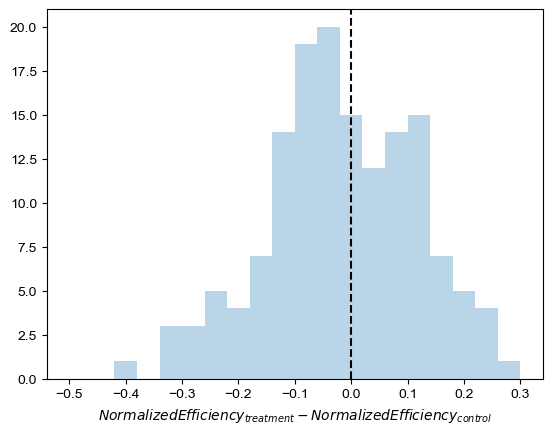

In [107]:
plt.hist(df_paired_learn["treatment_itt_efficiency"] - df_paired_learn["control_itt_efficiency"], bins=20, alpha=0.3, range=(-0.5,0.3))
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("$Normalized Efficiency_{treatment} - Normalized Efficiency_{control}$")

In [51]:
df_cluster_learn["cluster"].value_counts()

cluster
5     22
2     21
25    16
22    14
6     14
0     14
3     14
21    14
24    13
23    11
16    11
18    11
15    11
13    11
28    11
20    11
11    10
9     10
4     10
10     9
8      9
29     9
19     9
26     9
17     9
14     8
27     8
1      7
7      5
12     4
Name: count, dtype: int64

In [52]:
df_cluster_learn["cluster"].value_counts().mean()

11.166666666666666

In [119]:
learn_het_stats

{'Q': 38.83, 'Q_pval': 0.028, 'Q_dof': 24, 'i2': 0.38}

In [13]:
learn_het_stats, val_het_stats

({'Q': 29.01, 'Q_pval': 0.066, 'Q_dof': 19, 'i2': 0.34},
 {'Q': 30.29, 'Q_pval': 0.048, 'Q_dof': 19, 'i2': 0.37})

In [38]:
calc_q_i2(pd.concat([df_cluster_params.rename(columns={"estimate": "treatment_effect_mean", "se": "treatment_effect_se"}),
          df_paired_val[["treatment_effect_mean", "treatment_effect_se"]]], ignore_index=True))

{'Q': 59.34, 'Q_pval': 0.019, 'Q_dof': 39, 'i2': 0.34}

In [120]:
df_cluster_params.sort_values("estimate")

,cluster,estimate,se
17,17,-0.712771,0.586073
20,20,-0.569792,0.288800
21,21,-0.326207,0.196675
5,5,-0.286148,0.155056
12,12,-0.178290,0.091990
14,14,-0.171163,0.093871
6,6,-0.112069,0.120805
18,18,-0.098004,0.059946
3,3,-0.049201,0.110860
13,13,-0.043073,0.163513


In [29]:
df_cluster_learn.groupby(["cluster", "CONFIG_punishmentExists"])["itt_relative_efficiency"].agg(["mean", "size"])

mean  size
cluster CONFIG_punishmentExists                
0       With punishment          0.698817    11
        Without punishment       0.597880    11
1       With punishment          0.874610     3
        Without punishment       0.884627     4
2       With punishment          0.802144     8
        Without punishment       0.555775     9
3       With punishment          0.759123    10
        Without punishment       0.790077    11
4       With punishment          0.798482    10
        Without punishment       0.766893    11
5       With punishment          0.781257     4
        Without punishment       0.752354     4
6       With punishment          0.711330     9
        Without punishment       0.762528    11
7       With punishment          0.652997     5
        Without punishment       0.671678     5
8       With punishment          0.605961     9
        Without punishment       0.712982     9
9       With punishment          0.650360    11
        Without punishment       0.665556    10
10      With punishment          0.439470     6
        Without punishment       0.780100     7
11      With punishment          0.502885    16
        Without punishment       0.747242    16
12      With punishment          0.534627    12
        Without punishment       0.775114    10
13      With punishment          0.625673    11
        Without punishment       0.681647    11
14      With punishment          0.601348     5
        Without punishment       0.718741     6
15      With punishment          0.524073     5
        Without punishment       0.774469     6
16      With punishment          0.344658    10
        Without punishment       0.651599     8
17      With punishment          0.512842     9
        Without punishment       0.606731    10
18      With punishment          0.765769     4
        Without punishment       0.756859     5
19      With punishment          0.686300     6
        Without punishment       0.769591     7

In [24]:
df_paired_val["releff_diff"] = df_paired_val["treatment_itt_relative_efficiency"] - df_paired_val["control_itt_relative_efficiency"]

In [28]:
df_paired_val.sort_values("releff_diff").filter(regex="CONFIG_conf|releff_diff|treatment_itt_rel|control_itt_rel")

,CONFIG_configId,treatment_itt_relative_efficiency,control_itt_relative_efficiency,releff_diff
3,1,0.397473,0.717841,-0.320369
4,5,0.585779,0.889664,-0.303886
17,16,0.639883,0.852213,-0.212330
2,10,0.538198,0.692602,-0.154405
15,15,0.589923,0.697174,-0.107251
16,9,0.574141,0.677913,-0.103773
9,7,0.815830,0.904525,-0.088695
11,8,0.538148,0.620211,-0.082063
13,14,0.749553,0.810521,-0.060969
10,6,0.669560,0.712231,-0.042670


In [22]:
df_analysis_val.query("valid_number_of_starting_players").groupby(["CONFIG_configId", "CONFIG_punishmentExists"])["itt_relative_efficiency"].agg(["mean", "size"])

mean  size
CONFIG_configId CONFIG_punishmentExists                
0               False                    0.714614    10
                True                     0.786788    12
1               False                    0.717841     8
                True                     0.397473     8
2               False                    0.601015     9
                True                     0.585645    11
3               False                    0.625639     9
                True                     0.805342    10
4               False                    0.667659    12
                True                     0.640999     9
5               False                    0.889664     9
                True                     0.585779    12
6               False                    0.712231    12
                True                     0.669560    11
7               False                    0.904525    11
                True                     0.815830    12
8               False                    0.620211    12
                True                     0.538148    11
9               False                    0.677913    11
                True                     0.574141    11
10              False                    0.692602    10
                True                     0.538198    10
11              False                    0.769996    10
                True                     0.788152    11
12              False                    0.748754    12
                True                     0.825239    12
13              False                    0.853450    10
                True                     0.862523    11
14              False                    0.810521    12
                True                     0.749553    10
15              False                    0.697174    11
                True                     0.589923     9
16              False                    0.852213    10
                True                     0.639883     8
17              False                    0.620493    11
                True                     0.653386     8
18              False                    0.620170    12
                True                     0.684843    10
19              False                    0.619210    10
                True                     0.666724    10

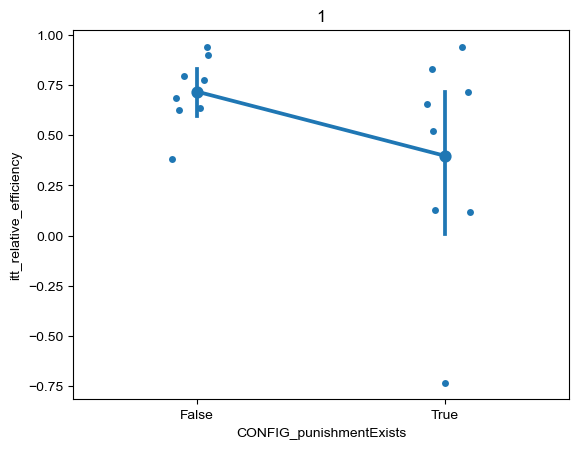

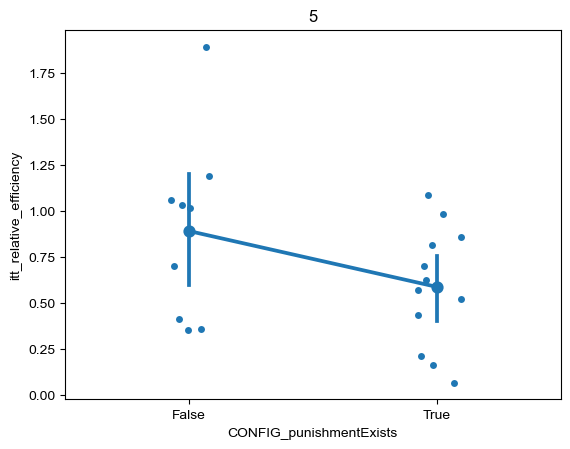

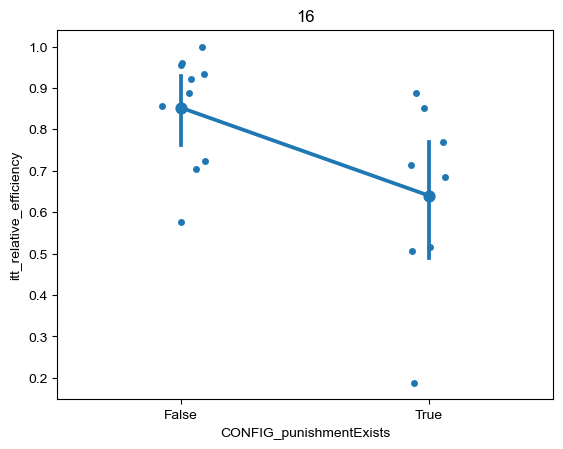

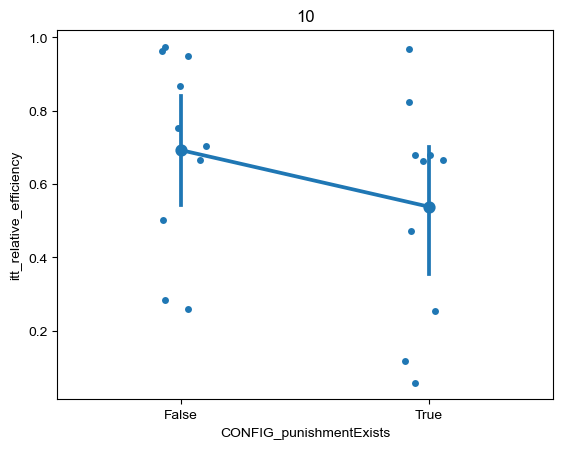

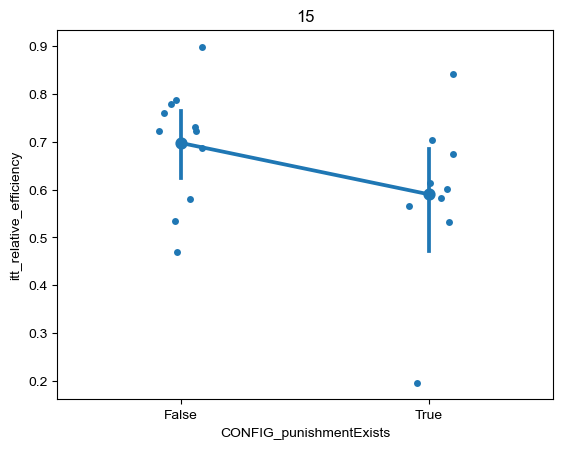

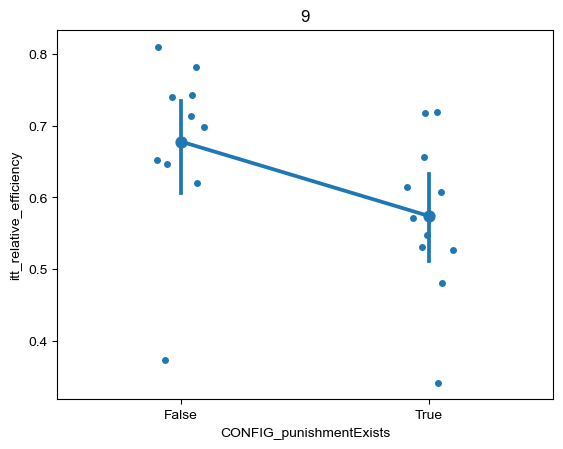

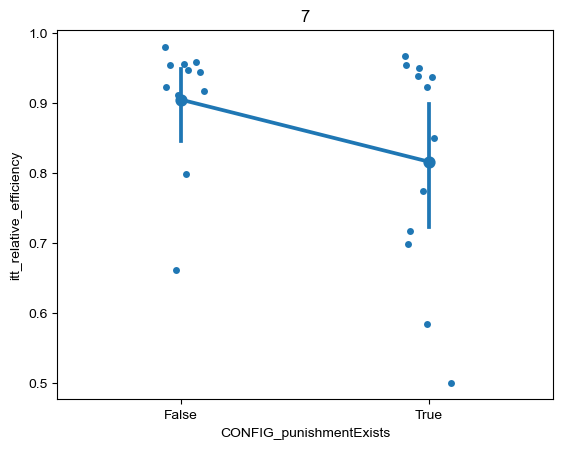

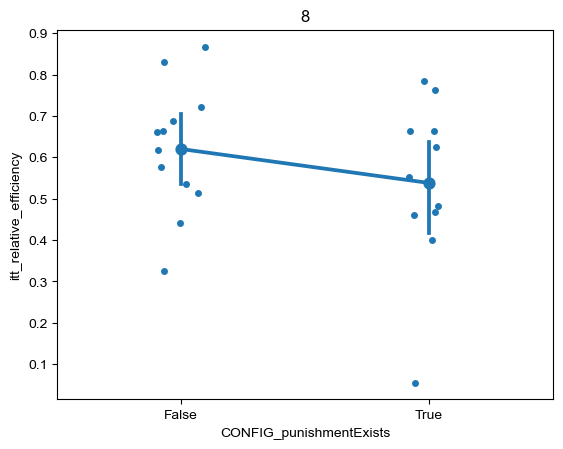

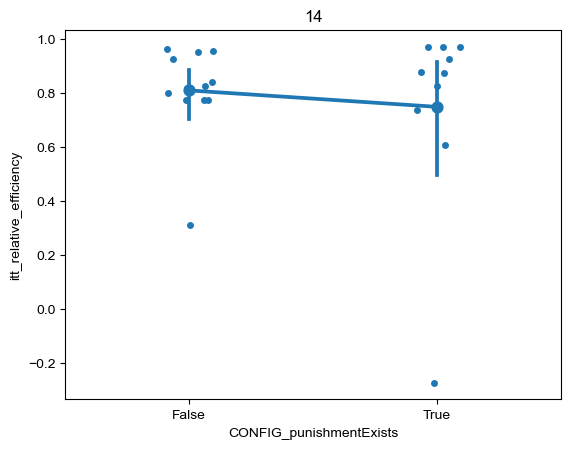

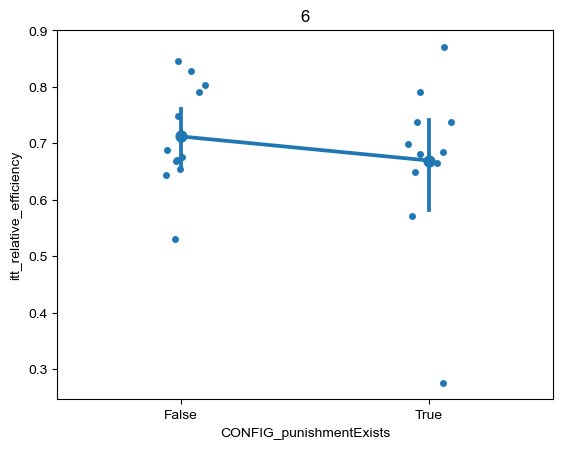

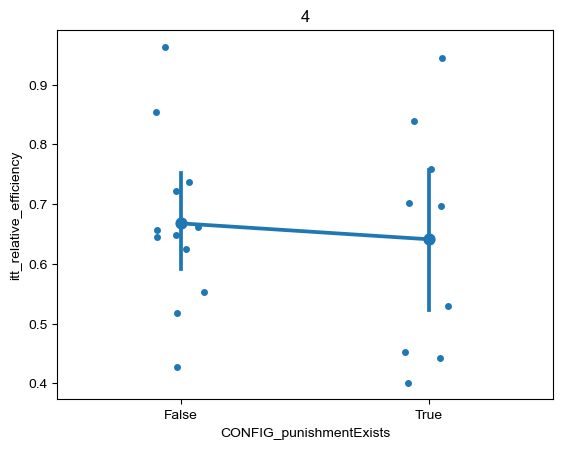

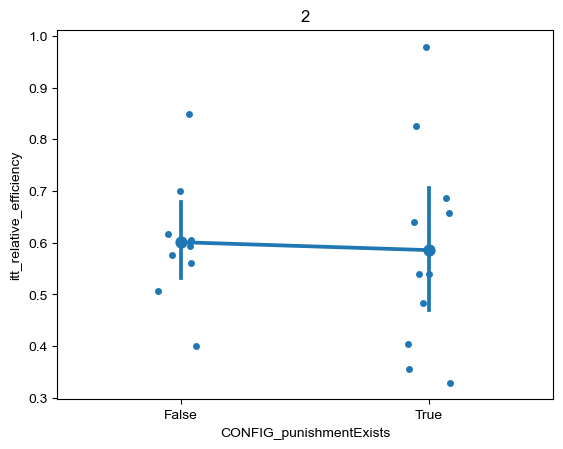

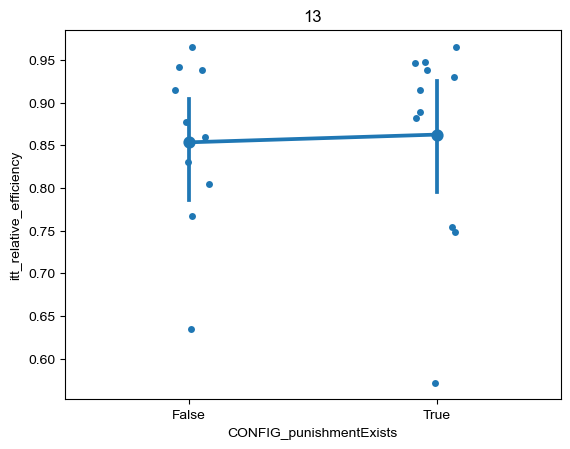

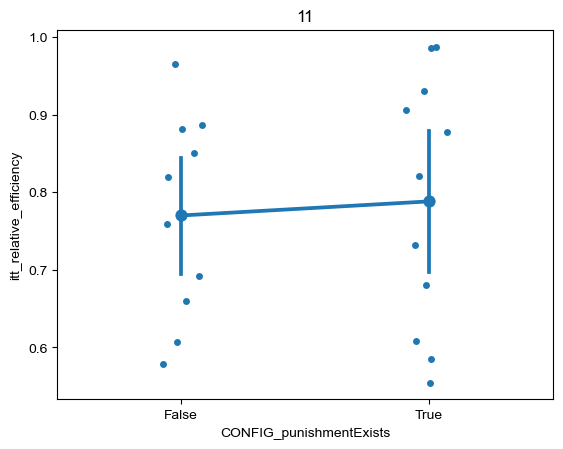

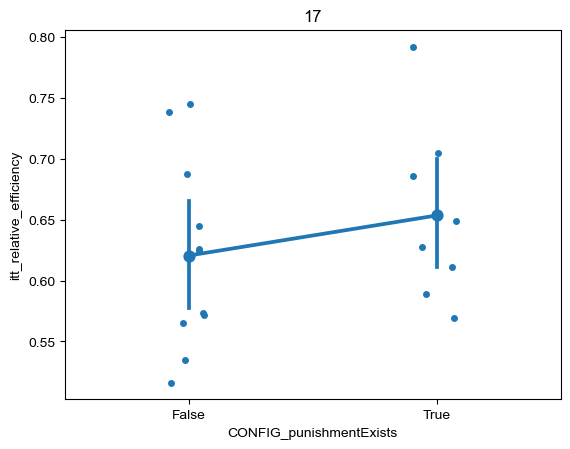

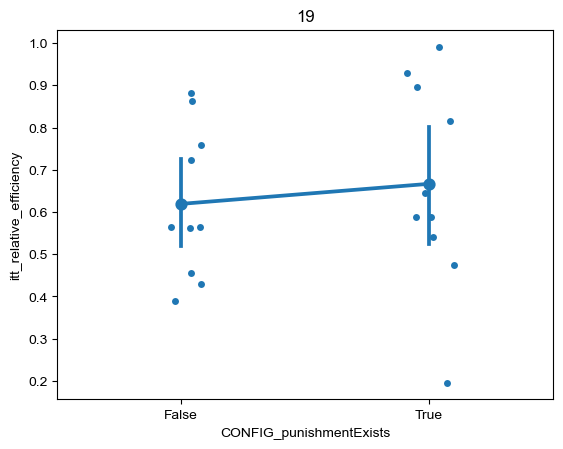

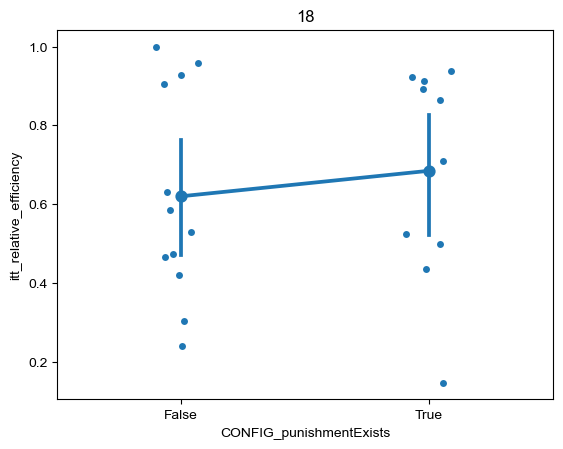

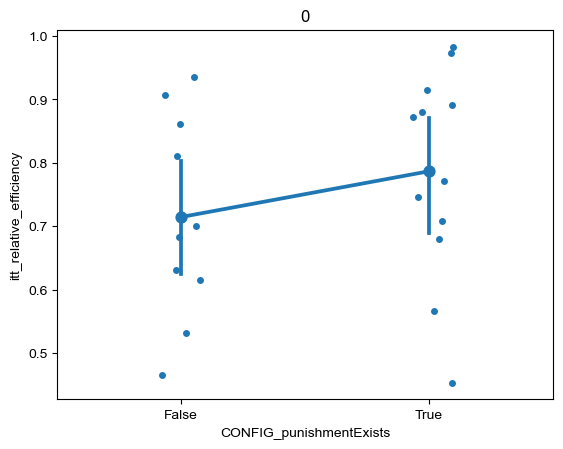

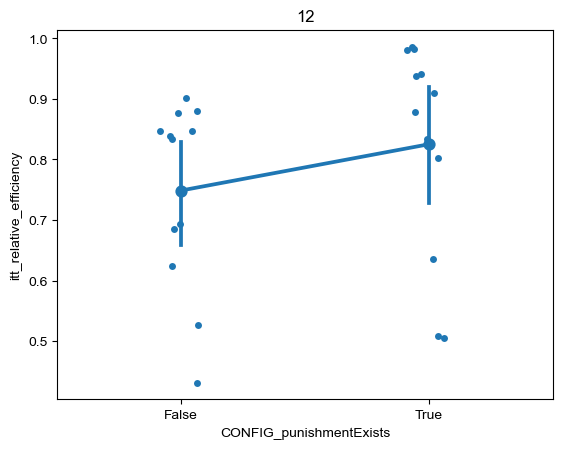

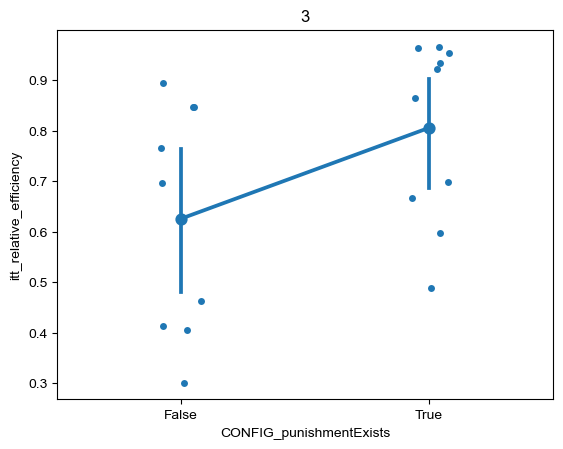

In [36]:
for config_id in df_paired_val.sort_values("releff_diff")["CONFIG_configId"].values:
    sns.pointplot(x="CONFIG_punishmentExists", y="itt_relative_efficiency", data=df_analysis_val.query("valid_number_of_starting_players and CONFIG_configId == @config_id"))
    sns.stripplot(x="CONFIG_punishmentExists", y="itt_relative_efficiency", data=df_analysis_val.query("valid_number_of_starting_players and CONFIG_configId == @config_id"))
    plt.title(config_id)
    plt.show()